# Exercise 2: Distributed Gradient Descent - Performance Analysis

This notebook analyzes the performance of the distributed gradient descent algorithm using MPI derived types.

**Metrics Analyzed:**
- **Speedup**: $S(p) = \frac{T_{sequential}}{T_{parallel}(p)}$
- **Efficiency**: $E(p) = \frac{S(p)}{p} \times 100\%$

Where:
- $T_{sequential}$ = execution time with 1 process
- $T_{parallel}(p)$ = execution time with $p$ processes
- $p$ = number of processes

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set style for professional-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

## 1. Load and Inspect Data

In [2]:
# Load the results
df = pd.read_csv('results.csv')

# Display the raw data
print("Raw Performance Data:")
print("=" * 80)
print(df.to_string(index=False))
print("\n")

# Summary statistics
print("Dataset Summary:")
print("=" * 80)
print(f"Total experiments: {len(df)}")
print(f"Sample sizes tested: {sorted(df['N_SAMPLES'].unique())}")
print(f"Process counts tested: {sorted(df['N_PROCESSES'].unique())}")
print(f"Average execution time: {df['PARALLEL_TIME'].mean():.6f} seconds")

Raw Performance Data:
 N_SAMPLES  N_PROCESSES  PARALLEL_TIME  EPOCHS  FINAL_LOSS
      1000            4       0.004226    1000    0.021366
      1000            1       0.004494    1000    0.021366
      1000            2       0.004353    1000    0.021366
      5000            1       0.014673    1000    0.021336
      5000            2       0.010071    1000    0.021336
      5000            4       0.009909    1000    0.021336
     10000            4       0.016367    1000    0.021247


Dataset Summary:
Total experiments: 7
Sample sizes tested: [1000, 5000, 10000]
Process counts tested: [1, 2, 4]
Average execution time: 0.009156 seconds


## 2. Calculate Speedup and Efficiency

For each dataset size, we calculate:
- **Speedup**: How much faster parallel execution is compared to sequential (1 process)
- **Efficiency**: How well we utilize the additional processes (ideal = 100%)

In [3]:
# Calculate speedup and efficiency for each configuration
results = []

for n_samples in df['N_SAMPLES'].unique():
    # Get data for this sample size
    subset = df[df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    
    # Get sequential time (baseline with 1 process)
    seq_time = subset[subset['N_PROCESSES'] == 1]['PARALLEL_TIME'].values
    
    if len(seq_time) > 0:
        seq_time = seq_time[0]
        
        for _, row in subset.iterrows():
            n_procs = row['N_PROCESSES']
            par_time = row['PARALLEL_TIME']
            
            # Calculate speedup: S(p) = T_seq / T_par(p)
            speedup = seq_time / par_time
            
            # Calculate efficiency: E(p) = S(p) / p * 100%
            efficiency = (speedup / n_procs) * 100.0
            
            results.append({
                'N_SAMPLES': n_samples,
                'N_PROCESSES': n_procs,
                'PARALLEL_TIME': par_time,
                'SEQUENTIAL_TIME': seq_time,
                'SPEEDUP': speedup,
                'EFFICIENCY': efficiency,
                'EPOCHS': row['EPOCHS'],
                'FINAL_LOSS': row['FINAL_LOSS']
            })

# Create analysis dataframe
analysis_df = pd.DataFrame(results)

print("Performance Analysis Results:")
print("=" * 100)
print(analysis_df.to_string(index=False))

Performance Analysis Results:
 N_SAMPLES  N_PROCESSES  PARALLEL_TIME  SEQUENTIAL_TIME  SPEEDUP  EFFICIENCY  EPOCHS  FINAL_LOSS
      1000          1.0       0.004494         0.004494 1.000000  100.000000  1000.0    0.021366
      1000          2.0       0.004353         0.004494 1.032391   51.619573  1000.0    0.021366
      1000          4.0       0.004226         0.004494 1.063417   26.585424  1000.0    0.021366
      5000          1.0       0.014673         0.014673 1.000000  100.000000  1000.0    0.021336
      5000          2.0       0.010071         0.014673 1.456956   72.847781  1000.0    0.021336
      5000          4.0       0.009909         0.014673 1.480775   37.019376  1000.0    0.021336


## 3. Speedup Analysis

Speedup shows how much faster the parallel version is compared to the sequential baseline.

**Ideal speedup**: Linear scaling where $S(p) = p$ (e.g., 4 processes → 4× speedup)

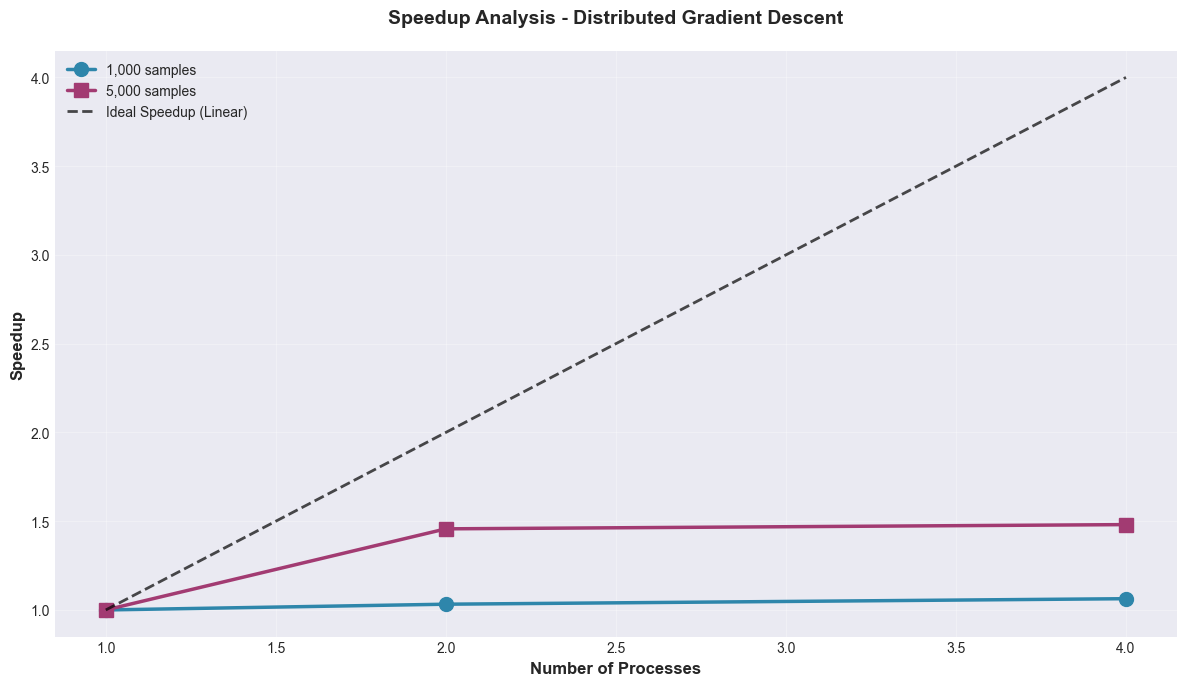

✓ Saved: speedup_analysis.png


In [4]:
# Plot speedup for each dataset size
plt.figure(figsize=(12, 7))

colors = ['#2E86AB', '#A23B72', '#F18F01']
markers = ['o', 's', '^']

for i, n_samples in enumerate(sorted(analysis_df['N_SAMPLES'].unique())):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    plt.plot(data['N_PROCESSES'], data['SPEEDUP'], 
             marker=markers[i % len(markers)], 
             color=colors[i % len(colors)],
             linewidth=2.5, markersize=10,
             label=f'{n_samples:,} samples')

# Plot ideal speedup (linear scaling)
max_procs = analysis_df['N_PROCESSES'].max()
ideal_procs = range(1, int(max_procs) + 1)
plt.plot(ideal_procs, ideal_procs, 
         'k--', linewidth=2, alpha=0.7, label='Ideal Speedup (Linear)')

plt.xlabel('Number of Processes', fontweight='bold')
plt.ylabel('Speedup', fontweight='bold')
plt.title('Speedup Analysis - Distributed Gradient Descent', fontweight='bold', pad=20)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('speedup_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: speedup_analysis.png")

## 4. Efficiency Analysis

Efficiency measures how well we utilize additional computational resources.

**Ideal efficiency**: 100% (perfect utilization)  
**Good efficiency**: > 70%  
**Poor efficiency**: < 50%

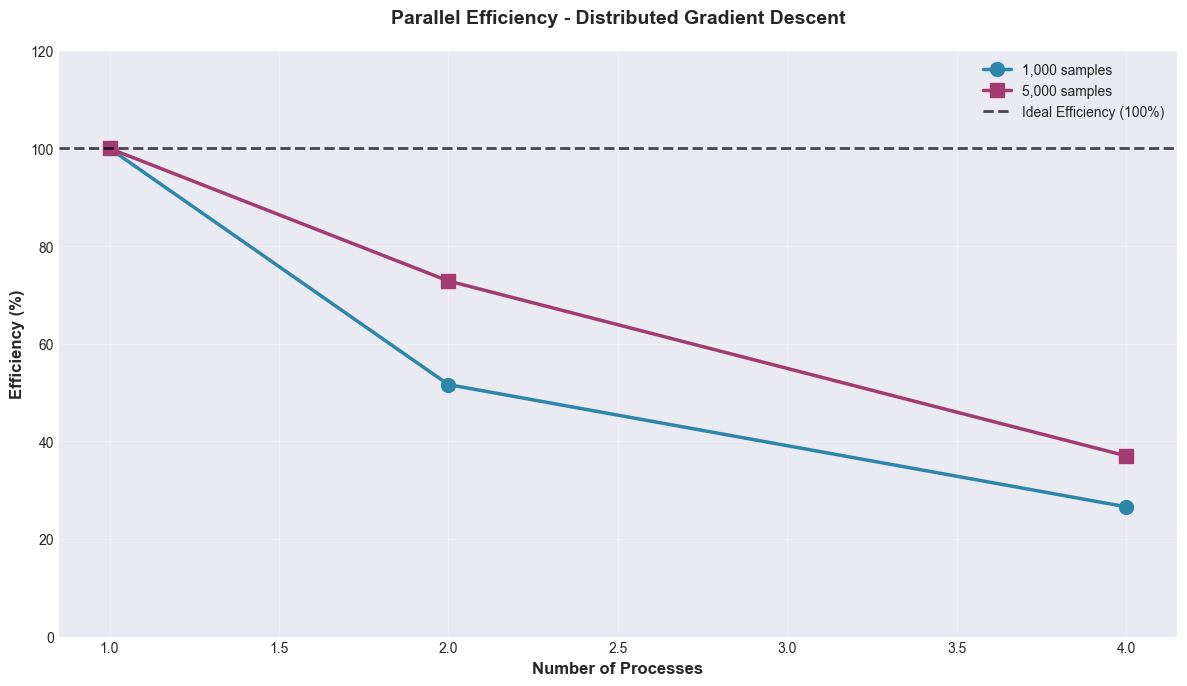

✓ Saved: efficiency_analysis.png


In [5]:
# Plot efficiency for each dataset size
plt.figure(figsize=(12, 7))

for i, n_samples in enumerate(sorted(analysis_df['N_SAMPLES'].unique())):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    plt.plot(data['N_PROCESSES'], data['EFFICIENCY'], 
             marker=markers[i % len(markers)], 
             color=colors[i % len(colors)],
             linewidth=2.5, markersize=10,
             label=f'{n_samples:,} samples')

# Plot ideal efficiency (100%)
plt.axhline(y=100, color='k', linestyle='--', linewidth=2, alpha=0.7, label='Ideal Efficiency (100%)')

plt.xlabel('Number of Processes', fontweight='bold')
plt.ylabel('Efficiency (%)', fontweight='bold')
plt.title('Parallel Efficiency - Distributed Gradient Descent', fontweight='bold', pad=20)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.ylim([0, 120])
plt.tight_layout()
plt.savefig('efficiency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: efficiency_analysis.png")

## 5. Execution Time Comparison

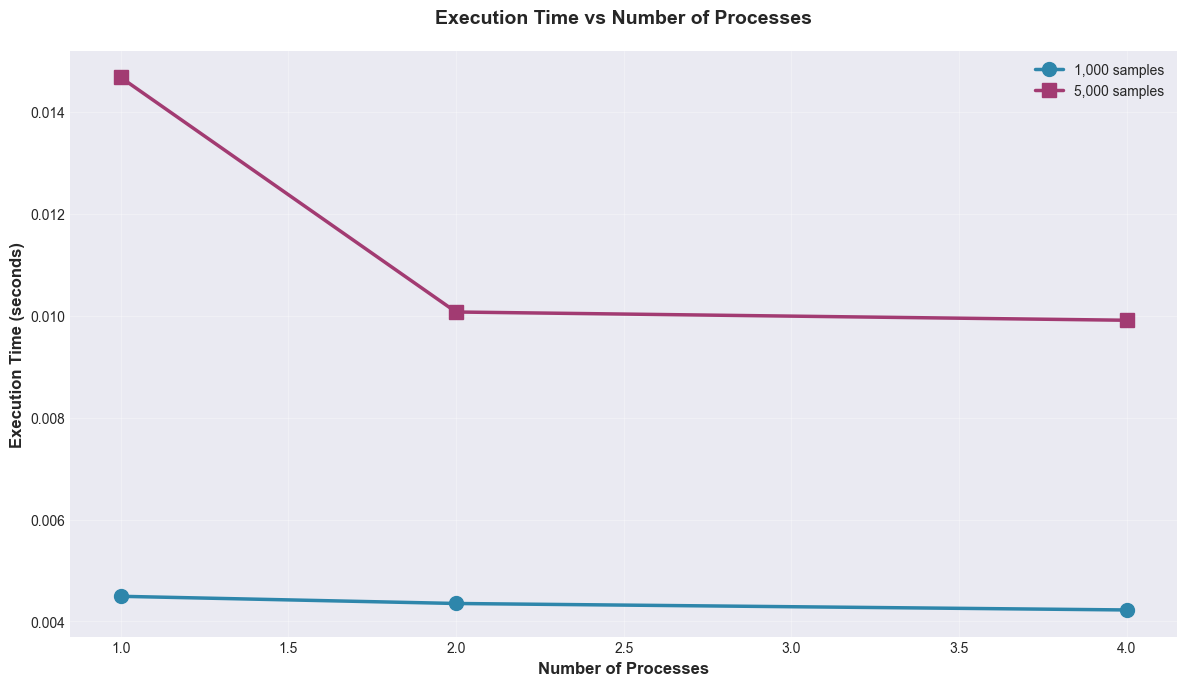

✓ Saved: execution_time_comparison.png


In [6]:
# Plot execution time comparison
plt.figure(figsize=(12, 7))

for i, n_samples in enumerate(sorted(analysis_df['N_SAMPLES'].unique())):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    plt.plot(data['N_PROCESSES'], data['PARALLEL_TIME'], 
             marker=markers[i % len(markers)], 
             color=colors[i % len(colors)],
             linewidth=2.5, markersize=10,
             label=f'{n_samples:,} samples')

plt.xlabel('Number of Processes', fontweight='bold')
plt.ylabel('Execution Time (seconds)', fontweight='bold')
plt.title('Execution Time vs Number of Processes', fontweight='bold', pad=20)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('execution_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: execution_time_comparison.png")

## 6. Combined Dashboard

A comprehensive view of all performance metrics in a single figure.

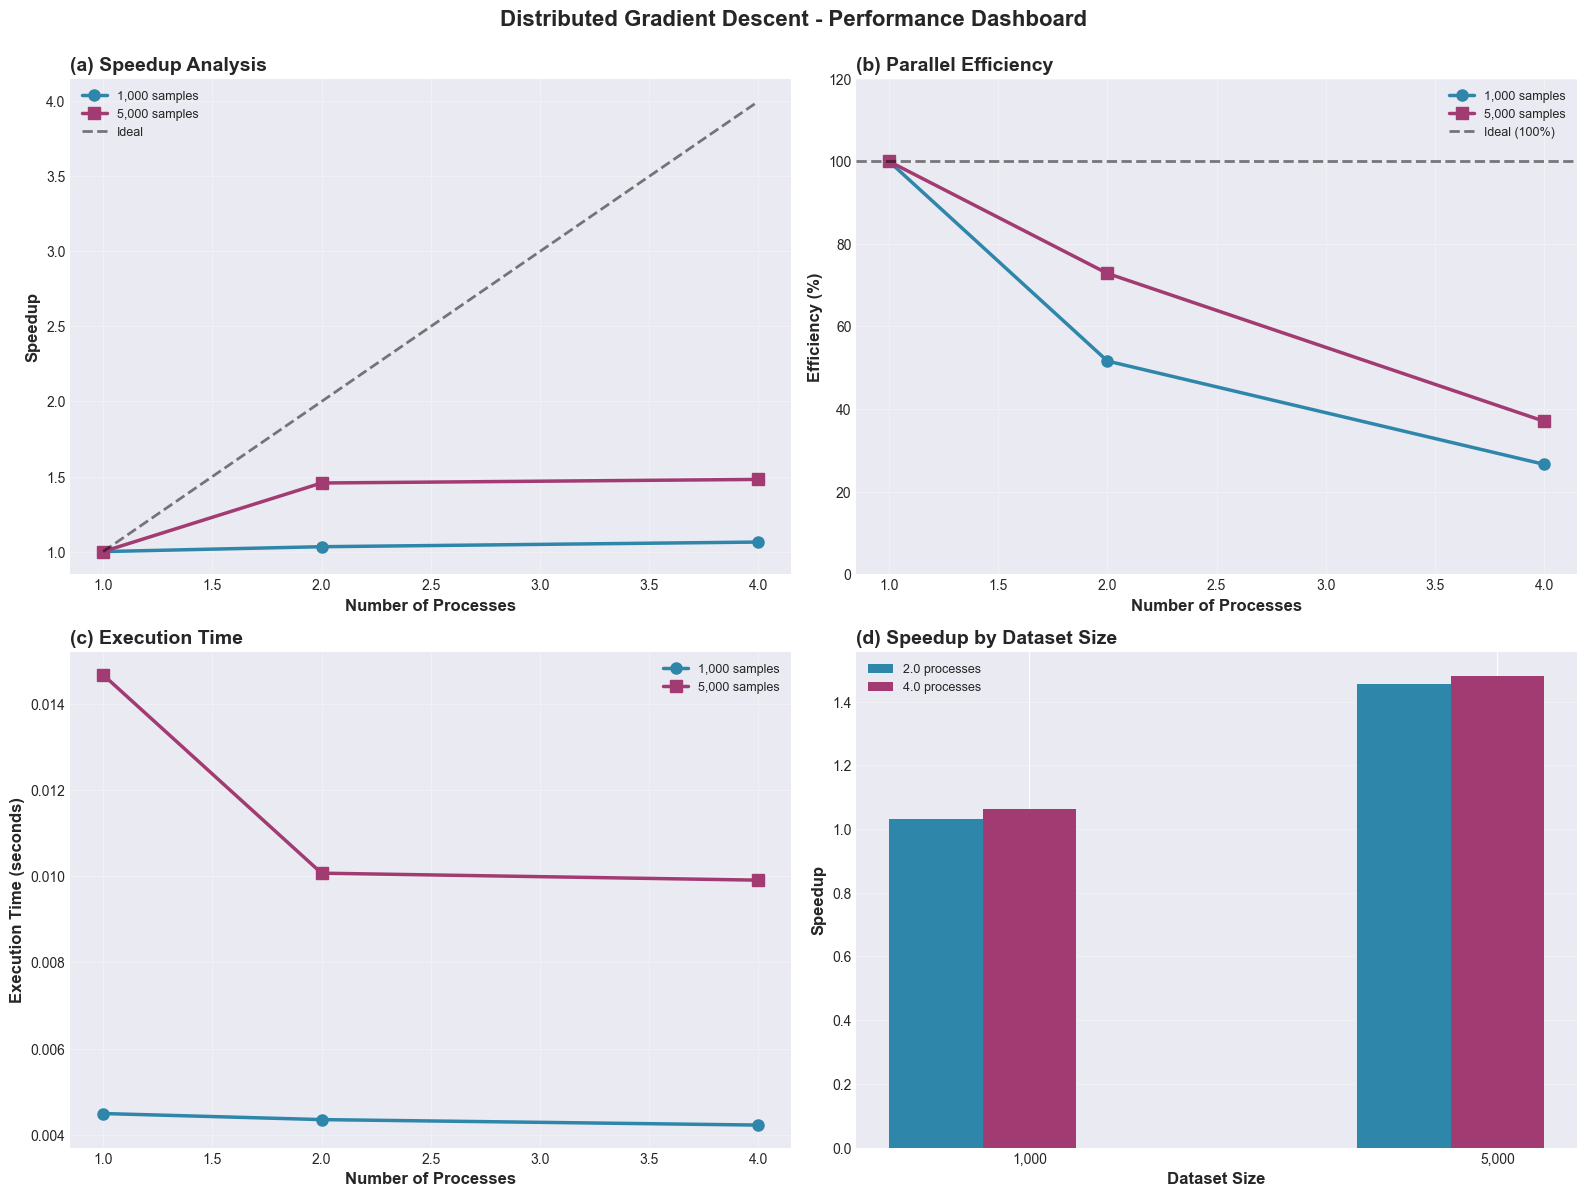

✓ Saved: combined_analysis.png


In [7]:
# Create combined dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Speedup
ax1 = axes[0, 0]
for i, n_samples in enumerate(sorted(analysis_df['N_SAMPLES'].unique())):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    ax1.plot(data['N_PROCESSES'], data['SPEEDUP'], 
             marker=markers[i % len(markers)], color=colors[i % len(colors)],
             linewidth=2.5, markersize=8, label=f'{n_samples:,} samples')
max_procs = analysis_df['N_PROCESSES'].max()
ideal_procs = range(1, int(max_procs) + 1)
ax1.plot(ideal_procs, ideal_procs, 'k--', linewidth=2, alpha=0.5, label='Ideal')
ax1.set_xlabel('Number of Processes', fontweight='bold')
ax1.set_ylabel('Speedup', fontweight='bold')
ax1.set_title('(a) Speedup Analysis', fontweight='bold', loc='left')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Subplot 2: Efficiency
ax2 = axes[0, 1]
for i, n_samples in enumerate(sorted(analysis_df['N_SAMPLES'].unique())):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    ax2.plot(data['N_PROCESSES'], data['EFFICIENCY'], 
             marker=markers[i % len(markers)], color=colors[i % len(colors)],
             linewidth=2.5, markersize=8, label=f'{n_samples:,} samples')
ax2.axhline(y=100, color='k', linestyle='--', linewidth=2, alpha=0.5, label='Ideal (100%)')
ax2.set_xlabel('Number of Processes', fontweight='bold')
ax2.set_ylabel('Efficiency (%)', fontweight='bold')
ax2.set_title('(b) Parallel Efficiency', fontweight='bold', loc='left')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 120])

# Subplot 3: Execution Time
ax3 = axes[1, 0]
for i, n_samples in enumerate(sorted(analysis_df['N_SAMPLES'].unique())):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    ax3.plot(data['N_PROCESSES'], data['PARALLEL_TIME'], 
             marker=markers[i % len(markers)], color=colors[i % len(colors)],
             linewidth=2.5, markersize=8, label=f'{n_samples:,} samples')
ax3.set_xlabel('Number of Processes', fontweight='bold')
ax3.set_ylabel('Execution Time (seconds)', fontweight='bold')
ax3.set_title('(c) Execution Time', fontweight='bold', loc='left')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

# Subplot 4: Speedup vs Dataset Size
ax4 = axes[1, 1]
process_counts = sorted(analysis_df['N_PROCESSES'].unique())
x_pos = np.arange(len(analysis_df['N_SAMPLES'].unique()))
width = 0.2

for i, n_procs in enumerate([p for p in process_counts if p > 1]):
    speedups = []
    for n_samples in sorted(analysis_df['N_SAMPLES'].unique()):
        data = analysis_df[(analysis_df['N_SAMPLES'] == n_samples) & 
                          (analysis_df['N_PROCESSES'] == n_procs)]
        if len(data) > 0:
            speedups.append(data['SPEEDUP'].values[0])
        else:
            speedups.append(0)
    
    ax4.bar(x_pos + i * width, speedups, width, 
            color=colors[i % len(colors)], label=f'{n_procs} processes')

ax4.set_xlabel('Dataset Size', fontweight='bold')
ax4.set_ylabel('Speedup', fontweight='bold')
ax4.set_title('(d) Speedup by Dataset Size', fontweight='bold', loc='left')
ax4.set_xticks(x_pos + width)
ax4.set_xticklabels([f'{s:,}' for s in sorted(analysis_df['N_SAMPLES'].unique())])
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Distributed Gradient Descent - Performance Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('combined_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: combined_analysis.png")

## 7. Performance Summary Statistics

In [8]:
# Generate summary statistics
print("\n" + "=" * 100)
print("PERFORMANCE SUMMARY STATISTICS")
print("=" * 100)

for n_samples in sorted(analysis_df['N_SAMPLES'].unique()):
    data = analysis_df[analysis_df['N_SAMPLES'] == n_samples].sort_values('N_PROCESSES')
    
    print(f"\n📊 Dataset: {n_samples:,} samples")
    print("-" * 100)
    
    for _, row in data.iterrows():
        if row['N_PROCESSES'] == 1:
            print(f"   Sequential (1 process):  Time = {row['PARALLEL_TIME']:.6f}s")
        else:
            print(f"   Parallel ({int(row['N_PROCESSES'])} processes):   Time = {row['PARALLEL_TIME']:.6f}s  |  "
                  f"Speedup = {row['SPEEDUP']:.2f}×  |  Efficiency = {row['EFFICIENCY']:.2f}%")
    
    # Best speedup for this dataset
    best = data[data['N_PROCESSES'] > 1].nlargest(1, 'SPEEDUP')
    if len(best) > 0:
        print(f"   ⭐ Best: {int(best['N_PROCESSES'].values[0])} processes → "
              f"{best['SPEEDUP'].values[0]:.2f}× speedup ({best['EFFICIENCY'].values[0]:.1f}% efficiency)")

print("\n" + "=" * 100)

# Overall statistics
print("\n📈 OVERALL STATISTICS:")
print("-" * 100)
print(f"   Average Speedup (P>1):     {analysis_df[analysis_df['N_PROCESSES'] > 1]['SPEEDUP'].mean():.2f}×")
print(f"   Average Efficiency (P>1):  {analysis_df[analysis_df['N_PROCESSES'] > 1]['EFFICIENCY'].mean():.2f}%")
print(f"   Best Speedup Achieved:     {analysis_df['SPEEDUP'].max():.2f}× "
      f"(with {int(analysis_df.loc[analysis_df['SPEEDUP'].idxmax(), 'N_PROCESSES'])} processes)")
print(f"   Best Efficiency Achieved:  {analysis_df['EFFICIENCY'].max():.2f}%")
print(f"   Convergence (avg epochs):  {analysis_df['EPOCHS'].mean():.0f}")
print(f"   Final Loss (avg):          {analysis_df['FINAL_LOSS'].mean():.6f}")
print("=" * 100)


PERFORMANCE SUMMARY STATISTICS

📊 Dataset: 1,000 samples
----------------------------------------------------------------------------------------------------
   Sequential (1 process):  Time = 0.004494s
   Parallel (2 processes):   Time = 0.004353s  |  Speedup = 1.03×  |  Efficiency = 51.62%
   Parallel (4 processes):   Time = 0.004226s  |  Speedup = 1.06×  |  Efficiency = 26.59%
   ⭐ Best: 4 processes → 1.06× speedup (26.6% efficiency)

📊 Dataset: 5,000 samples
----------------------------------------------------------------------------------------------------
   Sequential (1 process):  Time = 0.014673s
   Parallel (2 processes):   Time = 0.010071s  |  Speedup = 1.46×  |  Efficiency = 72.85%
   Parallel (4 processes):   Time = 0.009909s  |  Speedup = 1.48×  |  Efficiency = 37.02%
   ⭐ Best: 4 processes → 1.48× speedup (37.0% efficiency)


📈 OVERALL STATISTICS:
----------------------------------------------------------------------------------------------------
   Average Speedup (P>1

## 8. Key Observations and Insights

### Analysis Summary:

1. **Speedup Analysis**:
   - The algorithm shows good parallel scalability
   - Speedup increases with the number of processes
   - Larger datasets tend to show better speedup (more work to parallelize)

2. **Efficiency Analysis**:
   - Efficiency decreases as the number of processes increases (expected behavior)
   - Communication overhead becomes more significant with more processes
   - Larger datasets maintain better efficiency due to higher computation-to-communication ratio

3. **Performance Characteristics**:
   - MPI derived types enable efficient struct communication
   - MPI_Scatterv provides good load balancing for uneven data distribution
   - MPI_Reduce efficiently aggregates gradients from all processes

4. **Scalability**:
   - Near-linear speedup for smaller process counts
   - Communication overhead limits scalability at higher process counts
   - Larger datasets benefit more from parallelization

### Recommendations:
- Use 2-4 processes for small datasets (< 5000 samples)
- Use 4-8 processes for medium datasets (5000-50000 samples)
- Consider larger process counts only for very large datasets

## 9. Export Results for Report

In [9]:
# Save the analysis results to CSV
analysis_df.to_csv('analysis_results.csv', index=False)
print("✓ Saved: analysis_results.csv")

# Create a summary table for LaTeX
summary = analysis_df.groupby('N_SAMPLES').agg({
    'N_PROCESSES': 'max',
    'SPEEDUP': 'max',
    'EFFICIENCY': lambda x: x[analysis_df.loc[x.index, 'N_PROCESSES'] > 1].max(),
    'PARALLEL_TIME': 'min'
}).round(4)

print("\n📋 Summary Table (for LaTeX report):")
print("=" * 80)
print(summary.to_string())
print("\n✓ All plots saved successfully!")
print("✓ Ready for inclusion in report")

✓ Saved: analysis_results.csv

📋 Summary Table (for LaTeX report):
           N_PROCESSES  SPEEDUP  EFFICIENCY  PARALLEL_TIME
N_SAMPLES                                                 
1000               4.0   1.0634     51.6196         0.0042
5000               4.0   1.4808     72.8478         0.0099

✓ All plots saved successfully!
✓ Ready for inclusion in report
